In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [13]:
df = pd.read_csv(r"E:\new_kaggle\Unemployment in India.csv")

In [14]:
import os

print(os.listdir(r"E:\new_kaggle"))

['Unemployment in India.csv', 'Unemployment.ipynb']


In [15]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
df.shape

(768, 7)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [18]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [19]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [20]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [21]:
# Remove extra spaces from Date values

In [34]:
df["Date"] = pd.to_datetime(df["Date"].astype(str).str.strip(), dayfirst=True)

df["Month"] = df["Date"].dt.strftime("%b")

In [35]:
print(df["Date"].dtype)
print(df["Date"].head())

datetime64[ns]
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


## Exploratory Data Analysis (EDA)

In [24]:
print(df.isnull().sum())

df = df.dropna()

print(df.shape)

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
(740, 7)


In [25]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


## Region-wise Average Unemployment Rate

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10976\2695310419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


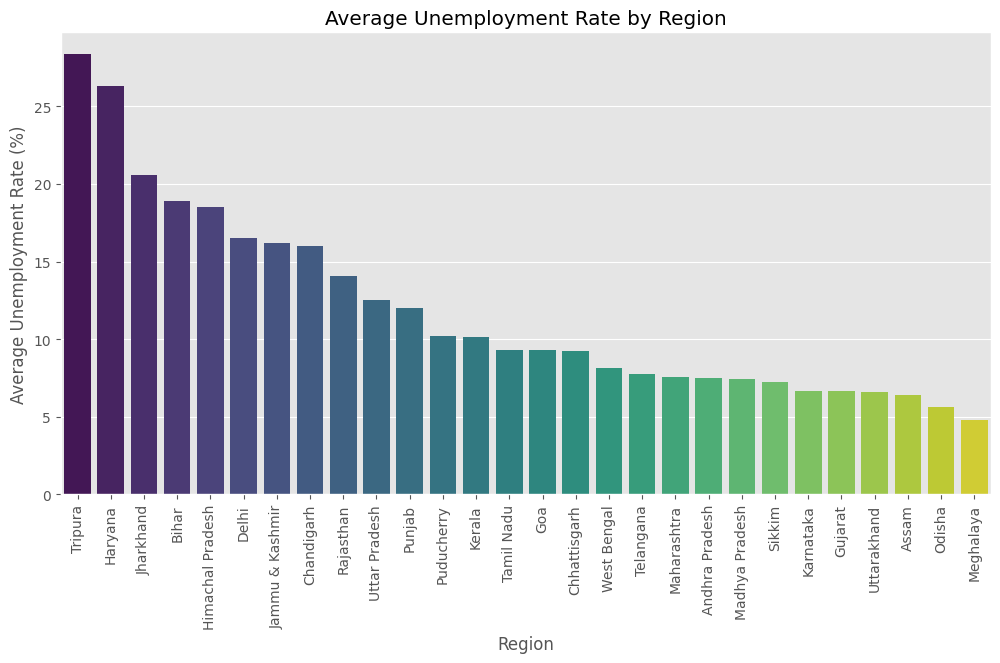

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    x=region_avg.index,
    y=region_avg.values,
    palette="viridis"
)

plt.xticks(rotation=90)
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

Observation: The chart shows that unemployment rates vary significantly across regions. 
Some states consistently report higher average unemployment than others, 
indicating regional economic differences and varying employment opportunities.

## Month-wise Unemployment Trend

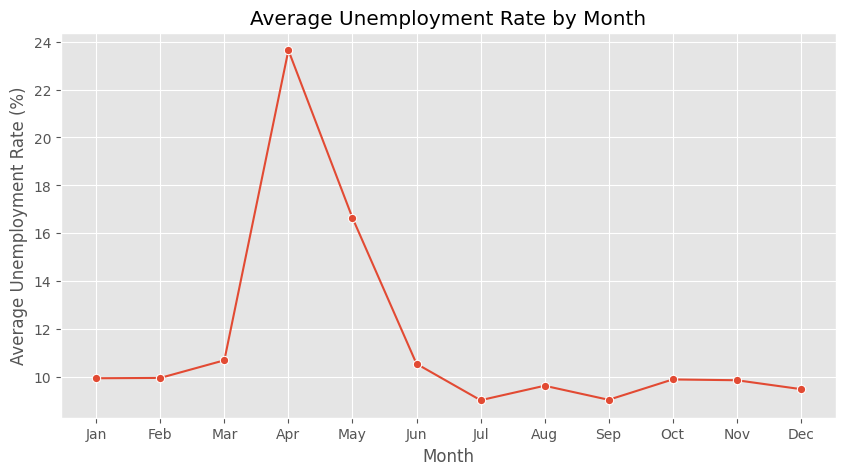

In [47]:
df["Month"] = df["Date"].dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

month_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean().reindex(month_order)

plt.figure(figsize=(10,5))
sns.lineplot(x=month_avg.index, y=month_avg.values, marker="o")

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

### Observation

The unemployment rate changes across different months, showing seasonal variations. Some months experienced relatively higher unemployment rates than others.

## Time-Series Analysis of Major States

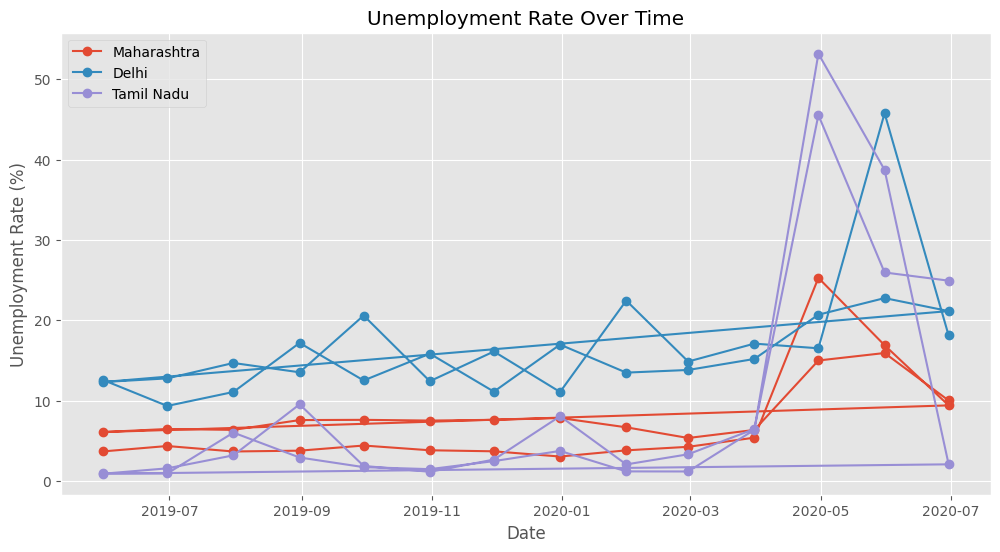

In [37]:
states = ["Maharashtra", "Delhi", "Tamil Nadu"]

plt.figure(figsize=(12,6))

for state in states:
    state_data = df[df["Region"] == state]
    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.show()

### Observation

The unemployment trends differ across states. Some states experienced sharp increases during certain months, while others showed relatively stable unemployment rates over time.

## Top 10 States with Highest Average Unemployment Rate

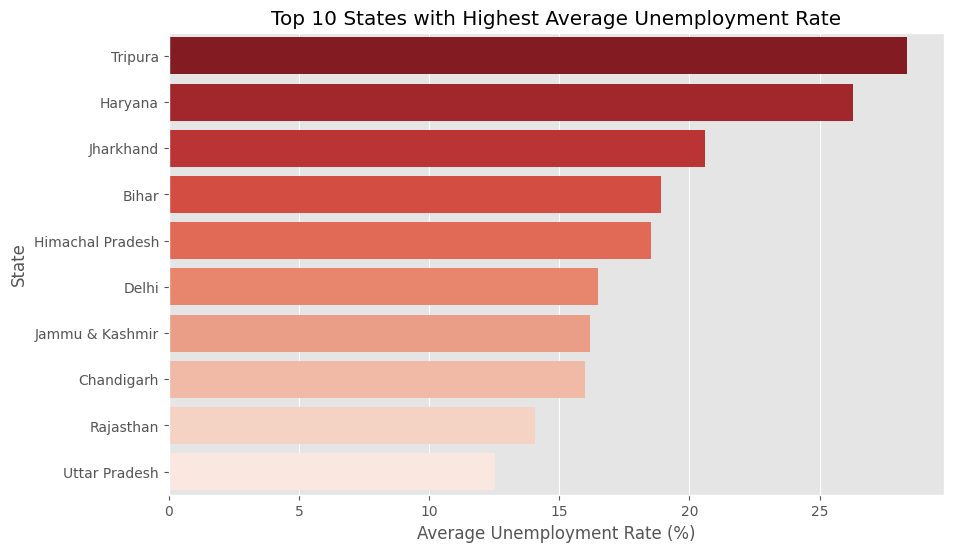

In [40]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"] \
          .mean() \
          .sort_values(ascending=False) \
          .head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

### Observation

The chart highlights the ten states with the highest average unemployment rates, indicating regions that may require stronger employment and economic development initiatives.

## Correlation Heatmap

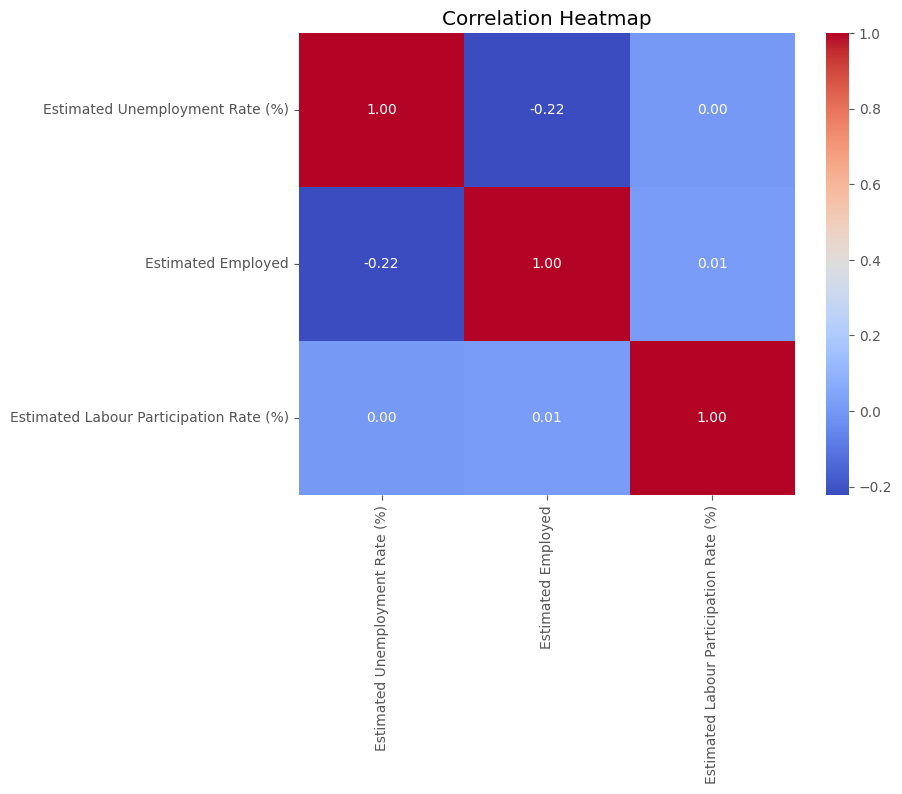

In [41]:
plt.figure(figsize=(8,6))

corr = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observation

The heatmap shows the relationship between unemployment rate, employment, and labour participation rate. It helps identify whether these variables are positively or negatively correlated.

## Pre-COVID vs Post-COVID Comparison

In [43]:
# Split dataset
pre_covid = df[df["Date"] < "2020-03-24"]
post_covid = df[df["Date"] >= "2020-03-24"]

# Mean unemployment rate
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


In [45]:
# Bar chart

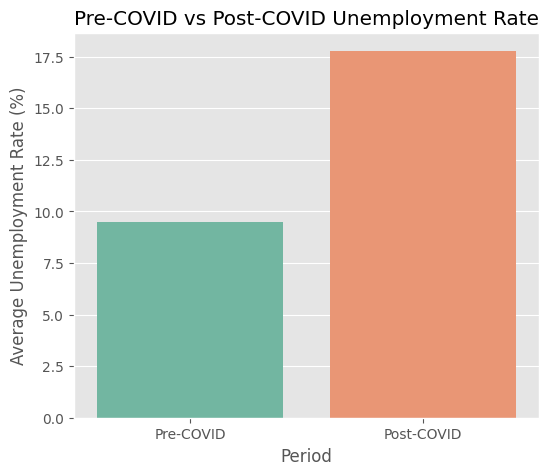

In [44]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate",
    hue="Period",
    palette="Set2",
    legend=False
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

### Observation

The average unemployment rate increased during the post-COVID period compared to the pre-COVID period. This reflects the significant impact of the COVID-19 pandemic on employment across India.